# CHGNet vs MACE — Co-Bi stoichiometry sweep comparison

Relaxes identical Co-Bi candidate structures with both CHGNet and MACE-MP-0,
using multiprocessing (6 cores) for parallelism. Compares:

- Formation energies per atom
- Predicted convex hulls
- Wall-clock relaxation time
- Convergence behaviour (steps, residual forces)

## Lattice structure types

We use **common binary intermetallic prototypes** (substitution templates):

| Prototype | Strukturbericht | Stoichiometry | Lattice |
|-----------|----------------|---------------|----------|
| CsCl | B2 | AB | cubic |
| NaCl | B1 | AB | cubic (rocksalt) |
| ZnS | B3 | AB | cubic (zincblende) |
| NiAs | B8₁ | AB | hexagonal |
| FeSi | B20 | AB | cubic |
| Cu₃Au | L1₂ | A₃B | cubic (FCC-ordered) |
| Ni₃Sn | D0₁₉ | A₃B | hexagonal |
| MoSi₂ | C11b | AB₂ | tetragonal |
| CaF₂ | C1 | AB₂ | cubic (fluorite) |
| CaCu₅ | D2d | A₅B | hexagonal |

**Why these prototypes?** They cover the dominant coordination environments
and stoichiometries (1:1, 3:1, 2:1, 5:1) expected for transition-metal/post-
transition-metal binaries. The NiAs type is especially relevant — the known
stable Co-Bi phase (CoSb-like) adopts a NiAs-derived structure. By sweeping
all common prototypes we let the MLIP discriminate which structural motifs
are energetically competitive without biasing the search.

MLIP energies are *screening predictions* — they prioritise candidates for
DFT validation but do **not** prove thermodynamic stability.

In [1]:
from __future__ import annotations

import multiprocessing as mp
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pymatgen.core import Composition, Lattice, Structure

warnings.filterwarnings("ignore")

REPO = Path.cwd().resolve()
if not (REPO / "data").is_dir() and (REPO.parent / "data").is_dir():
    REPO = REPO.parent
if not (REPO / "data").is_dir():
    raise FileNotFoundError(
        f"Expected data/ under {REPO}. Open the notebook from the repo root."
    )

if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")

N_WORKERS = 6
print(f"REPO = {REPO}")
print(f"Multiprocessing workers: {N_WORKERS}")

REPO = /home/hhoechter/projects/hullgap
Multiprocessing workers: 6


## 1. Configuration

In [2]:
ELEMENT_A = "Co"
ELEMENT_B = "Bi"
SYSTEM = f"{ELEMENT_A}-{ELEMENT_B}"

MODELS = ["chgnet", "mace"]
FMAX = 0.05       # eV/Å
MAX_STEPS = 300

RESULTS_DIR = REPO / "data" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"System:   {SYSTEM}")
print(f"Models:   {MODELS}")
print(f"fmax:     {FMAX} eV/Å")
print(f"Steps:    {MAX_STEPS}")

System:   Co-Bi
Models:   ['chgnet', 'mace']
fmax:     0.05 eV/Å
Steps:    300


## 2. Generate candidate structures

Binary intermetallic prototypes — lattice parameters estimated from metallic radii.

In [3]:
RADII = {"Co": 1.25, "Bi": 1.55}  # metallic radii in Å


def avg_radius(species_list):
    return np.mean([RADII[s] for s in species_list])


def make_candidates(el_a, el_b):
    """Generate candidate structures across the full composition range."""
    r_avg = avg_radius([el_a, el_b])
    candidates = []

    # --- AB (1:1) prototypes ---
    a = 2 * r_avg / np.sqrt(3) * 2
    candidates.append(("CsCl_B2", Structure(
        Lattice.cubic(a),
        [el_a, el_b],
        [[0, 0, 0], [0.5, 0.5, 0.5]],
    )))

    a = 2 * r_avg * np.sqrt(2)
    candidates.append(("NaCl_B1", Structure(
        Lattice.cubic(a),
        [el_a]*4 + [el_b]*4,
        [
            [0, 0, 0], [0.5, 0.5, 0], [0.5, 0, 0.5], [0, 0.5, 0.5],
            [0.5, 0, 0], [0, 0.5, 0], [0, 0, 0.5], [0.5, 0.5, 0.5],
        ],
    )))

    a = 4 * r_avg / np.sqrt(3)
    candidates.append(("ZnS_B3", Structure(
        Lattice.cubic(a),
        [el_a]*4 + [el_b]*4,
        [
            [0, 0, 0], [0.5, 0.5, 0], [0.5, 0, 0.5], [0, 0.5, 0.5],
            [0.25, 0.25, 0.25], [0.75, 0.75, 0.25],
            [0.75, 0.25, 0.75], [0.25, 0.75, 0.75],
        ],
    )))

    a_hex = 2 * r_avg
    c_hex = a_hex * 1.63
    candidates.append(("NiAs_B81", Structure(
        Lattice.hexagonal(a_hex, c_hex),
        [el_a, el_a, el_b, el_b],
        [
            [0, 0, 0], [0, 0, 0.5],
            [1/3, 2/3, 0.25], [2/3, 1/3, 0.75],
        ],
    )))

    a = 2 * r_avg * 2.1
    candidates.append(("FeSi_B20", Structure(
        Lattice.cubic(a),
        [el_a]*4 + [el_b]*4,
        [
            [0.137, 0.137, 0.137], [0.637, 0.363, 0.863],
            [0.363, 0.863, 0.637], [0.863, 0.637, 0.363],
            [0.845, 0.845, 0.845], [0.345, 0.655, 0.155],
            [0.655, 0.155, 0.345], [0.155, 0.345, 0.655],
        ],
    )))

    # --- A3B (3:1) prototypes ---
    a = 2 * r_avg * np.sqrt(2)
    candidates.append(("Cu3Au_L12", Structure(
        Lattice.cubic(a),
        [el_a]*3 + [el_b],
        [[0.5, 0.5, 0], [0.5, 0, 0.5], [0, 0.5, 0.5], [0, 0, 0]],
    )))

    a_hex = 2 * r_avg * 2
    c_hex = a_hex * 0.82
    candidates.append(("Ni3Sn_D019", Structure(
        Lattice.hexagonal(a_hex, c_hex),
        [el_a]*6 + [el_b]*2,
        [
            [5/6, 2/3, 1/4], [1/6, 1/3, 3/4],
            [1/3, 1/3, 1/4], [2/3, 2/3, 3/4],
            [1/2, 0, 1/4], [1/2, 0, 3/4],
            [0, 0, 1/4], [0, 0, 3/4],
        ],
    )))

    # --- AB3 (1:3) — same prototypes, elements swapped ---
    a = 2 * r_avg * np.sqrt(2)
    candidates.append(("Au3Cu_L12", Structure(
        Lattice.cubic(a),
        [el_b]*3 + [el_a],
        [[0.5, 0.5, 0], [0.5, 0, 0.5], [0, 0.5, 0.5], [0, 0, 0]],
    )))

    a_hex = 2 * r_avg * 2
    c_hex = a_hex * 0.82
    candidates.append(("Sn3Ni_D019", Structure(
        Lattice.hexagonal(a_hex, c_hex),
        [el_b]*6 + [el_a]*2,
        [
            [5/6, 2/3, 1/4], [1/6, 1/3, 3/4],
            [1/3, 1/3, 1/4], [2/3, 2/3, 3/4],
            [1/2, 0, 1/4], [1/2, 0, 3/4],
            [0, 0, 1/4], [0, 0, 3/4],
        ],
    )))

    # --- AB2 (1:2) prototypes ---
    a_tet = 2 * r_avg * 1.1
    c_tet = a_tet * 2.5
    candidates.append(("MoSi2_C11b", Structure(
        Lattice.tetragonal(a_tet, c_tet),
        [el_a]*2 + [el_b]*4,
        [
            [0, 0, 0], [0.5, 0.5, 0.5],
            [0, 0, 1/3], [0, 0, 2/3],
            [0.5, 0.5, 1/3+0.5], [0.5, 0.5, 2/3-0.5],
        ],
    )))

    a = 2 * r_avg * np.sqrt(2) * 1.05
    candidates.append(("CaF2_C1", Structure(
        Lattice.cubic(a),
        [el_a]*4 + [el_b]*8,
        [
            [0, 0, 0], [0.5, 0.5, 0], [0.5, 0, 0.5], [0, 0.5, 0.5],
            [0.25, 0.25, 0.25], [0.75, 0.75, 0.25],
            [0.75, 0.25, 0.75], [0.25, 0.75, 0.75],
            [0.25, 0.25, 0.75], [0.75, 0.75, 0.75],
            [0.75, 0.25, 0.25], [0.25, 0.75, 0.25],
        ],
    )))

    candidates.append(("CaF2_C1_inv", Structure(
        Lattice.cubic(a),
        [el_b]*4 + [el_a]*8,
        [
            [0, 0, 0], [0.5, 0.5, 0], [0.5, 0, 0.5], [0, 0.5, 0.5],
            [0.25, 0.25, 0.25], [0.75, 0.75, 0.25],
            [0.75, 0.25, 0.75], [0.25, 0.75, 0.75],
            [0.25, 0.25, 0.75], [0.75, 0.75, 0.75],
            [0.75, 0.25, 0.25], [0.25, 0.75, 0.25],
        ],
    )))

    # --- A5B (5:1) ---
    a_hex = 2 * r_avg * 1.8
    c_hex = a_hex * 0.8
    candidates.append(("CaCu5_D2d", Structure(
        Lattice.hexagonal(a_hex, c_hex),
        [el_b] + [el_a]*5,
        [
            [0, 0, 0],
            [1/3, 2/3, 0], [2/3, 1/3, 0],
            [0, 1/2, 1/2], [1/2, 0, 1/2], [1/2, 1/2, 1/2],
        ],
    )))

    candidates.append(("CaCu5_D2d_inv", Structure(
        Lattice.hexagonal(a_hex, c_hex),
        [el_a] + [el_b]*5,
        [
            [0, 0, 0],
            [1/3, 2/3, 0], [2/3, 1/3, 0],
            [0, 1/2, 1/2], [1/2, 0, 1/2], [1/2, 1/2, 1/2],
        ],
    )))

    return candidates


candidates = make_candidates(ELEMENT_A, ELEMENT_B)

print(f"{len(candidates)} candidate structures generated:\n")
print(f"{'Prototype':<20s} {'Formula':<12s} {'x_Bi':>6s}  {'Atoms':>5s}")
print("-" * 48)
for name, struct in candidates:
    formula = struct.composition.reduced_formula
    comp = struct.composition
    x_b = comp.get_atomic_fraction(ELEMENT_B)
    print(f"{name:<20s} {formula:<12s} {x_b:6.3f}  {len(struct):5d}")

14 candidate structures generated:

Prototype            Formula        x_Bi  Atoms
------------------------------------------------
CsCl_B2              CoBi          0.500      2
NaCl_B1              CoBi          0.500      8
ZnS_B3               CoBi          0.500      8
NiAs_B81             CoBi          0.500      4
FeSi_B20             CoBi          0.500      8
Cu3Au_L12            Co3Bi         0.250      4
Ni3Sn_D019           Co3Bi         0.250      8
Au3Cu_L12            CoBi3         0.750      4
Sn3Ni_D019           CoBi3         0.750      8
MoSi2_C11b           CoBi2         0.667      6
CaF2_C1              CoBi2         0.667     12
CaF2_C1_inv          Co2Bi         0.333     12
CaCu5_D2d            Co5Bi         0.167      6
CaCu5_D2d_inv        CoBi5         0.833      6


## 3. Relaxation worker function

Each worker loads its own calculator instance (models are not pickle-safe),
then relaxes one structure.

In [4]:
from ase.filters import FrechetCellFilter
from ase.optimize import LBFGS
from pymatgen.io.ase import AseAtomsAdaptor


def _relax_single(args: tuple) -> dict:
    """
    Worker function for multiprocessing.
    Each process instantiates its own calculator to avoid pickling issues.
    """
    proto_name, struct_dict, model_name, fmax, max_steps = args

    from hullgap.calculators import get_calculator

    struct = Structure.from_dict(struct_dict)
    atoms = AseAtomsAdaptor.get_atoms(struct)

    try:
        calc = get_calculator(model_name)
        atoms.calc = calc

        opt_target = FrechetCellFilter(atoms)
        opt = LBFGS(opt_target, logfile=None)

        t0 = time.perf_counter()
        converged = opt.run(fmax=fmax, steps=max_steps)
        wall_time = time.perf_counter() - t0

        energy = float(atoms.get_potential_energy())
        forces = atoms.get_forces()
        max_force = float(np.max(np.linalg.norm(forces, axis=1)))
        n_atoms = len(atoms)
        volume = atoms.get_volume()

        return {
            "prototype": proto_name,
            "model": model_name,
            "formula": atoms.get_chemical_formula(mode="metal"),
            "n_atoms": n_atoms,
            "energy_total_eV": energy,
            "energy_per_atom_eV": energy / n_atoms,
            "max_force_eV_A": max_force,
            "volume_per_atom_A3": volume / n_atoms,
            "n_steps": opt.nsteps,
            "converged": bool(converged),
            "wall_time_s": wall_time,
            "status": "converged" if converged else "max_steps_reached",
            "error": "",
        }
    except Exception as exc:
        return {
            "prototype": proto_name,
            "model": model_name,
            "formula": struct.composition.reduced_formula,
            "n_atoms": len(struct),
            "energy_total_eV": np.nan,
            "energy_per_atom_eV": np.nan,
            "max_force_eV_A": np.nan,
            "volume_per_atom_A3": np.nan,
            "n_steps": 0,
            "converged": False,
            "wall_time_s": 0.0,
            "status": "failed",
            "error": str(exc),
        }


def relax_elemental(element: str, struct: Structure, model_name: str,
                    fmax: float = 0.02, max_steps: int = 500) -> float:
    """Relax an elemental structure and return energy per atom."""
    from hullgap.calculators import get_calculator

    atoms = AseAtomsAdaptor.get_atoms(struct)
    calc = get_calculator(model_name)
    atoms.calc = calc
    opt = LBFGS(FrechetCellFilter(atoms), logfile=None)
    opt.run(fmax=fmax, steps=max_steps)
    return float(atoms.get_potential_energy()) / len(atoms)


print("Worker function defined.")

Worker function defined.


## 4. Compute elemental reference energies for both models

In [5]:
ELEMENTAL_STRUCTURES = {
    "Co": Structure(
        Lattice.hexagonal(2.507, 4.069),
        ["Co", "Co"],
        [[1/3, 2/3, 1/4], [2/3, 1/3, 3/4]],
    ),
    "Bi": Structure(
        Lattice.rhombohedral(4.746, 57.23),
        ["Bi", "Bi"],
        [[0.234, 0.234, 0.234], [0.766, 0.766, 0.766]],
    ),
}

refs = {}  # {model: {element: energy_per_atom}}
for model_name in MODELS:
    refs[model_name] = {}
    for el, struct in ELEMENTAL_STRUCTURES.items():
        e_per_atom = relax_elemental(el, struct, model_name)
        refs[model_name][el] = e_per_atom
        print(f"  {model_name:8s}  {el:3s}  E/atom = {e_per_atom:.4f} eV")

print("\nReference energies:")
for m, r in refs.items():
    print(f"  {m}: {r}")

CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
  chgnet    Co   E/atom = -7.0292 eV
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
  chgnet    Bi   E/atom = -3.8241 eV
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /home/hhoechter/.cache/mace/macempa0mediummodel
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.
  mace      Co   E/atom = -7.1116 eV
Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /home/hhoechter/.cache/mace/macempa0mediummodel
Using float64 for MACECalculator, which is slower but mo

## 5. Run parallel relaxations (6 workers)

We relax all 14 candidates × 2 models = 28 tasks using `multiprocessing.Pool`.

In [11]:
tasks = []
for model_name in MODELS:
    for proto_name, struct in candidates[0:4]:
        tasks.append((
            proto_name,
            struct.as_dict(),
            model_name,
            FMAX,
            MAX_STEPS,
        ))

from hullgap.calculators.relax_worker import relax_single

print(f"Total tasks: {len(tasks)} ({len(candidates)} structures × {len(MODELS)} models)")
print(f"Running with {N_WORKERS} worker processes (spawn)...\n")

t_start = time.perf_counter()

ctx = mp.get_context("spawn")
with ctx.Pool(processes=N_WORKERS) as pool:
    results = pool.map(relax_single, tasks)

t_total = time.perf_counter() - t_start
print(f"\nAll relaxations complete in {t_total:.1f}s")
print(f"  Successful: {sum(1 for r in results if r['status'] != 'failed')}")
print(f"  Failed:     {sum(1 for r in results if r['status'] == 'failed')}")

Total tasks: 8 (14 structures × 2 models)
Running with 6 worker processes (spawn)...



/home/hhoechter/projects/hullgap/.venv/lib/python3.11/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/home/hhoechter/projects/hullgap/.venv/lib/python3.11/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu


/home/hhoechter/projects/hullgap/.venv/lib/python3.11/site-packages/chgnet/model/model.py:898: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  volumes = torch.tensor(volumes, dtype=TORCH_DTYPE, device=atomic_numbers.device)
/home/hhoechter/projects/hullgap/.venv/lib/python3.11/site-packages/chgnet/model/model.py:898: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  volumes = torch.tensor(volumes, dtype=TORCH_DTYPE, device=atomic_numbers.device)
/home/hhoechter/projects/hullgap/.venv/lib/python3.11/site-packages/chgnet/model/model.py:898: UserWarning: Converting a tensor with requires_grad=True to a scalar may 

Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /home/hhoechter/.cache/mace/macempa0mediummodel
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.
Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /home/hhoechter/.cache/mace/macempa0mediummodel
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


...

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /home/hhoechter/.cache/mace/macempa0mediummodel
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/home/hhoechter/projects/hullgap/.venv/lib/python3.11/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /home/hhoechter/.cache/mace/macempa0mediummodel
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/home/hhoechter/projects/hullgap/.venv/lib/python3.11/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)



All relaxations complete in 1956.1s
  Successful: 8
  Failed:     0


## 6. Formation energies & results table

In [12]:
df = pd.DataFrame(results)


def formation_energy(row):
    """Formation energy per atom from relaxation results."""
    if np.isnan(row["energy_total_eV"]):
        return np.nan
    comp = Composition(row["formula"])
    model = row["model"]
    amt_a = comp.get_atomic_fraction(ELEMENT_A) * comp.num_atoms
    amt_b = comp.get_atomic_fraction(ELEMENT_B) * comp.num_atoms
    e_ref = amt_a * refs[model][ELEMENT_A] + amt_b * refs[model][ELEMENT_B]
    return (row["energy_total_eV"] - e_ref) / comp.num_atoms


df["formation_energy_per_atom_eV"] = df.apply(formation_energy, axis=1)
df["x_Bi"] = df["formula"].apply(
    lambda f: Composition(f).get_atomic_fraction(ELEMENT_B)
)

display_cols = [
    "prototype", "model", "formula", "x_Bi",
    "energy_per_atom_eV", "formation_energy_per_atom_eV",
    "max_force_eV_A", "volume_per_atom_A3",
    "n_steps", "wall_time_s", "status",
]
df[display_cols].sort_values(["model", "formation_energy_per_atom_eV"])

,prototype,model,formula,x_Bi,energy_per_atom_eV,formation_energy_per_atom_eV,max_force_eV_A,volume_per_atom_A3,n_steps,wall_time_s,status
0,CsCl_B2,chgnet,BiCo,0.5,-4.962550,0.464105,2.037921e-06,17.888532,3,37.598003,converged
1,NaCl_B1,chgnet,Bi4Co4,0.5,-0.363307,5.063348,1.090372e-04,7.415309,300,1951.452530,max_steps_reached
3,NiAs_B81,chgnet,Bi2Co2,0.5,-0.208045,5.218610,1.735514e-01,7.109269,300,1939.598603,max_steps_reached
2,ZnS_B3,chgnet,Bi4Co4,0.5,7.975449,13.402103,8.373757e-03,3.813339,5,307.559523,converged
7,NiAs_B81,mace,Bi2Co2,0.5,-5.294808,0.189831,3.517600e-14,18.757803,14,235.597384,converged
4,CsCl_B2,mace,BiCo,0.5,-4.964558,0.520081,3.851351e-15,18.808201,3,52.280935,converged
5,NaCl_B1,mace,Bi4Co4,0.5,-4.954900,0.529739,5.902960e-14,20.086057,14,299.139019,converged
6,ZnS_B3,mace,Bi4Co4,0.5,11.298277,16.782917,6.189204e-02,3.499193,213,1819.136664,converged


## 7. Side-by-side comparison table

In [13]:
pivot = df.pivot_table(
    index="prototype",
    columns="model",
    values=["formation_energy_per_atom_eV", "wall_time_s", "n_steps", "max_force_eV_A"],
    aggfunc="first",
)

comparison = pd.DataFrame({
    "formula": df[df["model"] == "chgnet"].set_index("prototype")["formula"],
    "x_Bi": df[df["model"] == "chgnet"].set_index("prototype")["x_Bi"],
    "Ef_chgnet (eV/at)": pivot[("formation_energy_per_atom_eV", "chgnet")],
    "Ef_mace (eV/at)": pivot[("formation_energy_per_atom_eV", "mace")],
    "ΔEf (chgnet−mace)": (
        pivot[("formation_energy_per_atom_eV", "chgnet")]
        - pivot[("formation_energy_per_atom_eV", "mace")]
    ),
    "time_chgnet (s)": pivot[("wall_time_s", "chgnet")],
    "time_mace (s)": pivot[("wall_time_s", "mace")],
    "steps_chgnet": pivot[("n_steps", "chgnet")],
    "steps_mace": pivot[("n_steps", "mace")],
})

comparison = comparison.sort_values("x_Bi")
comparison.style.format({
    "x_Bi": "{:.3f}",
    "Ef_chgnet (eV/at)": "{:.4f}",
    "Ef_mace (eV/at)": "{:.4f}",
    "ΔEf (chgnet−mace)": "{:.4f}",
    "time_chgnet (s)": "{:.2f}",
    "time_mace (s)": "{:.2f}",
    "steps_chgnet": "{:.0f}",
    "steps_mace": "{:.0f}",
}).background_gradient(subset=["ΔEf (chgnet−mace)"], cmap="RdBu", vmin=-0.3, vmax=0.3)

,formula,x_Bi,Ef_chgnet (eV/at),Ef_mace (eV/at),ΔEf (chgnet−mace),time_chgnet (s),time_mace (s),steps_chgnet,steps_mace
prototype,,,,,,,,,
CsCl_B2,BiCo,0.500,0.4641,0.5201,-0.0560,37.60,52.28,3,3
NaCl_B1,Bi4Co4,0.500,5.0633,0.5297,4.5336,1951.45,299.14,300,14
NiAs_B81,Bi2Co2,0.500,5.2186,0.1898,5.0288,1939.60,235.60,300,14
ZnS_B3,Bi4Co4,0.500,13.4021,16.7829,-3.3808,307.56,1819.14,5,213


## 8. Convex hull overlay plot

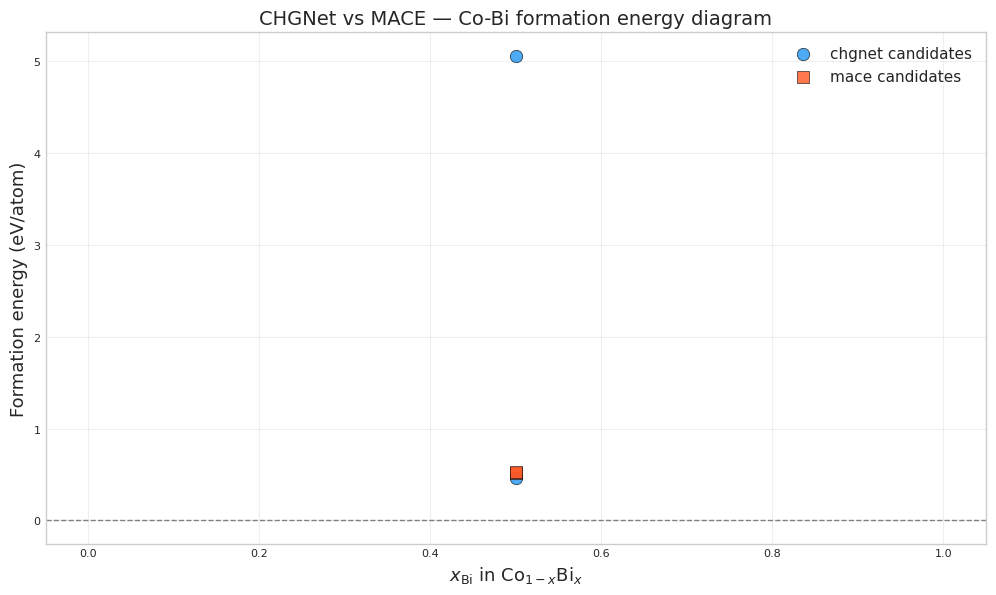

Saved: /home/hhoechter/projects/hullgap/data/results/chgnet_vs_mace_Co-Bi_hull.png


In [10]:
from scipy.spatial import ConvexHull


def compute_hull_line(x, ef):
    """Compute lower convex hull for a formation energy diagram."""
    points = np.column_stack([x, ef])
    points_with_endpoints = np.vstack([[0, 0], points, [1, 0]])

    hull = ConvexHull(points_with_endpoints)
    hull_x = []
    hull_y = []
    for simplex in hull.simplices:
        for idx in simplex:
            if points_with_endpoints[idx, 1] <= 0 or idx in [0, len(points_with_endpoints)-1]:
                hull_x.append(points_with_endpoints[idx, 0])
                hull_y.append(points_with_endpoints[idx, 1])

    pts = sorted(set(zip(hull_x, hull_y)))
    lower = [(0, 0)]
    for px, py in sorted(pts):
        if py <= 0:
            lower.append((px, py))
    lower.append((1, 0))

    # Graham scan for lower hull
    lower_sorted = sorted(set(lower))
    hull_pts = []
    for p in lower_sorted:
        while len(hull_pts) >= 2:
            o, a, b = hull_pts[-2], hull_pts[-1], p
            cross = (a[0]-o[0])*(b[1]-o[1]) - (a[1]-o[1])*(b[0]-o[0])
            if cross >= 0:
                hull_pts.pop()
            else:
                break
        hull_pts.append(p)

    hx = [p[0] for p in hull_pts]
    hy = [p[1] for p in hull_pts]
    return hx, hy


fig, ax = plt.subplots(figsize=(10, 6))

colors = {"chgnet": "#2196F3", "mace": "#FF5722"}
markers = {"chgnet": "o", "mace": "s"}

for model_name in MODELS:
    mdf = df[(df["model"] == model_name) & df["formation_energy_per_atom_eV"].notna()]
    x = mdf["x_Bi"].values
    ef = mdf["formation_energy_per_atom_eV"].values

    ax.scatter(
        x, ef,
        c=colors[model_name],
        marker=markers[model_name],
        s=80, alpha=0.8, edgecolors="k", linewidths=0.5,
        label=f"{model_name} candidates",
        zorder=3,
    )

    neg_mask = ef < 0
    if neg_mask.sum() >= 1:
        hx, hy = compute_hull_line(x[neg_mask], ef[neg_mask])
        ax.plot(hx, hy, "-", color=colors[model_name], lw=2, alpha=0.7,
                label=f"{model_name} hull")

ax.axhline(0, color="gray", ls="--", lw=1)
ax.set_xlabel(f"$x_{{\\mathrm{{{ELEMENT_B}}}}}$ in {ELEMENT_A}$_{{1-x}}${ELEMENT_B}$_x$", fontsize=13)
ax.set_ylabel("Formation energy (eV/atom)", fontsize=13)
ax.set_title(f"CHGNet vs MACE — {SYSTEM} formation energy diagram", fontsize=14)
ax.set_xlim(-0.05, 1.05)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(RESULTS_DIR / f"chgnet_vs_mace_{SYSTEM}_hull.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / f'chgnet_vs_mace_{SYSTEM}_hull.png'}")

## 9. Model agreement analysis

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# --- Panel 1: formation energy correlation ---
chg = df[df["model"] == "chgnet"].set_index("prototype")["formation_energy_per_atom_eV"]
mac = df[df["model"] == "mace"].set_index("prototype")["formation_energy_per_atom_eV"]
common = chg.index.intersection(mac.index)
chg_vals = chg.loc[common].values
mac_vals = mac.loc[common].values

valid = ~(np.isnan(chg_vals) | np.isnan(mac_vals))
chg_v = chg_vals[valid]
mac_v = mac_vals[valid]

ax = axes[0]
ax.scatter(chg_v, mac_v, s=60, alpha=0.8, edgecolors="k", linewidths=0.5)
lims = [min(chg_v.min(), mac_v.min()) - 0.1, max(chg_v.max(), mac_v.max()) + 0.1]
ax.plot(lims, lims, "--", color="gray", lw=1)
ax.set_xlabel("CHGNet Ef (eV/atom)")
ax.set_ylabel("MACE Ef (eV/atom)")
ax.set_title("Formation energy correlation")

mae = np.mean(np.abs(chg_v - mac_v))
rmse = np.sqrt(np.mean((chg_v - mac_v)**2))
ax.text(0.05, 0.95, f"MAE = {mae:.4f} eV/at\nRMSE = {rmse:.4f} eV/at",
        transform=ax.transAxes, va="top", fontsize=10,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

# --- Panel 2: wall time comparison ---
ax = axes[1]
chg_t = df[df["model"] == "chgnet"].set_index("prototype")["wall_time_s"]
mac_t = df[df["model"] == "mace"].set_index("prototype")["wall_time_s"]
protos = chg_t.index.intersection(mac_t.index)

x_pos = np.arange(len(protos))
width = 0.35
ax.barh(x_pos - width/2, chg_t.loc[protos].values, width, color=colors["chgnet"], label="CHGNet")
ax.barh(x_pos + width/2, mac_t.loc[protos].values, width, color=colors["mace"], label="MACE")
ax.set_yticks(x_pos)
ax.set_yticklabels(protos, fontsize=8)
ax.set_xlabel("Wall time (s)")
ax.set_title("Relaxation time per structure")
ax.legend(fontsize=9)

# --- Panel 3: steps comparison ---
ax = axes[2]
chg_s = df[df["model"] == "chgnet"].set_index("prototype")["n_steps"]
mac_s = df[df["model"] == "mace"].set_index("prototype")["n_steps"]

ax.barh(x_pos - width/2, chg_s.loc[protos].values, width, color=colors["chgnet"], label="CHGNet")
ax.barh(x_pos + width/2, mac_s.loc[protos].values, width, color=colors["mace"], label="MACE")
ax.set_yticks(x_pos)
ax.set_yticklabels(protos, fontsize=8)
ax.set_xlabel("Optimisation steps")
ax.set_title("Steps to convergence")
ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(RESULTS_DIR / f"chgnet_vs_mace_{SYSTEM}_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Summary statistics

In [ ]:
print("=" * 60)
print("SUMMARY: CHGNet vs MACE for Co-Bi")
print("=" * 60)

for model_name in MODELS:
    mdf = df[df["model"] == model_name]
    ok = mdf[mdf["status"] != "failed"]
    neg_ef = ok[ok["formation_energy_per_atom_eV"] < 0]
    print(f"\n  {model_name.upper()}:")
    print(f"    Converged:       {(ok['status']=='converged').sum()}/{len(ok)}")
    print(f"    Negative Ef:     {len(neg_ef)} prototypes")
    if len(neg_ef) > 0:
        best = neg_ef.loc[neg_ef["formation_energy_per_atom_eV"].idxmin()]
        print(f"    Most stable:     {best['prototype']} ({best['formula']})")
        print(f"                     Ef = {best['formation_energy_per_atom_eV']:.4f} eV/atom")
    print(f"    Mean wall time:  {ok['wall_time_s'].mean():.2f}s")
    print(f"    Total wall time: {ok['wall_time_s'].sum():.1f}s")

print(f"\n  Model agreement (valid pairs):")
print(f"    MAE(Ef):   {mae:.4f} eV/atom")
print(f"    RMSE(Ef):  {rmse:.4f} eV/atom")
print(f"    Spearman:  {pd.Series(chg_v).corr(pd.Series(mac_v), method='spearman'):.4f}")

# Rank agreement for top candidates
chg_rank = df[df["model"]=="chgnet"].sort_values("formation_energy_per_atom_eV")["prototype"].tolist()
mac_rank = df[df["model"]=="mace"].sort_values("formation_energy_per_atom_eV")["prototype"].tolist()
print(f"\n  Ranking (most stable first):")
print(f"    CHGNet: {chg_rank[:5]}")
print(f"    MACE:   {mac_rank[:5]}")
print("=" * 60)

## 11. Save results

In [ ]:
csv_path = RESULTS_DIR / f"chgnet_vs_mace_{SYSTEM}.csv"
df.to_csv(csv_path, index=False)
print(f"Results saved to: {csv_path}")